# Random Forest

**Join.ipynb** (después del BLOQUE 6) exporta:
- `Datos/Trusted/train_balanceado.csv` — entrenamiento (~180k filas)
- `Datos/Trusted/test_modelo.csv` — evaluación (~1,5M filas)

No uses `datos_modelo.csv` completo (7,4M filas): agota la RAM al leer.

In [ ]:
# %pip install scikit-learn pandas numpy

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score,
)

RUTA_TRAIN = Path("../Datos/Trusted/train_balanceado.csv")
RUTA_TEST = Path("../Datos/Trusted/test_modelo.csv")
RANDOM_STATE = 42
CHUNK_SIZE = 200_000

## 1. Cargar train balanceado

In [6]:
if not RUTA_TRAIN.exists():
    raise FileNotFoundError(
        f"No existe {RUTA_TRAIN}.\n"
        "En Join.ipynb ejecuta BLOQUE 6 y la celda de exportación."
    )

train = pd.read_csv(RUTA_TRAIN, parse_dates=["TW"], low_memory=False)
print(f"train_balanceado: {train.shape[0]:,} filas x {train.shape[1]} columnas")

y_train_bal = train["target"].astype(int)
cols_excluir = {"target", "TW", "BARRIO", "summary", "summary_agrupado"}
cols_X = [c for c in train.columns if c not in cols_excluir]
cols_X = [c for c in cols_X if pd.api.types.is_numeric_dtype(train[c])]

X_train_bal = train[cols_X].astype(np.float32)
print(f"Features: {len(cols_X)}")
display(
    y_train_bal.value_counts()
    .sort_index()
    .to_frame("cantidad")
    .assign(porcentaje=lambda x: (x["cantidad"] / len(y_train_bal) * 100).round(2))
)

train_balanceado: 176,116 filas x 30 columnas
Features: 27


,cantidad,porcentaje
target,,
0,88058,50.0
1,88058,50.0


## 2. Entrenar Random Forest

In [7]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Entrenando en muestra balanceada...")
modelo_rf.fit(X_train_bal, y_train_bal)
print("Listo.")

Entrenando en muestra balanceada...
Listo.


## 3. Evaluar en test (lectura por chunks)

In [8]:
if not RUTA_TEST.exists():
    raise FileNotFoundError(f"No existe {RUTA_TEST}. Exporta desde Join.ipynb.")

y_true_all = []
y_pred_all = []
y_proba_all = []

print("Prediciendo test por chunks...")
for i, chunk in enumerate(pd.read_csv(RUTA_TEST, parse_dates=["TW"], chunksize=CHUNK_SIZE, low_memory=False)):
    y_chunk = chunk["target"].astype(int)
    X_chunk = chunk[cols_X].astype(np.float32)
    y_pred_all.append(modelo_rf.predict(X_chunk))
    y_proba_all.append(modelo_rf.predict_proba(X_chunk)[:, 1])
    y_true_all.append(y_chunk.to_numpy())
    if (i + 1) % 5 == 0:
        print(f"  chunk {i + 1}...")

y_test = np.concatenate(y_true_all)
y_pred = np.concatenate(y_pred_all)
y_proba = np.concatenate(y_proba_all)

print(f"\nTest evaluado: {len(y_test):,} filas")
print("=" * 70)
print("RANDOM FOREST — TEST")
print("=" * 70)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

display(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"],
))
print(classification_report(y_test, y_pred, zero_division=0))

Prediciendo test por chunks...
  chunk 5...

Test evaluado: 1,458,412 filas
RANDOM FOREST — TEST
Accuracy:  0.7090
Precision: 0.0421
Recall:    0.7494
F1:        0.0797
PR-AUC:    0.0769
ROC-AUC:   0.8069


,Pred 0,Pred 1
Real 0,1015595,418300
Real 1,6143,18374


              precision    recall  f1-score   support

           0       0.99      0.71      0.83   1433895
           1       0.04      0.75      0.08     24517

    accuracy                           0.71   1458412
   macro avg       0.52      0.73      0.45   1458412
weighted avg       0.98      0.71      0.81   1458412



,umbral,precision,recall,f1,verdaderos_positivos,falsos_positivos,falsos_negativos,verdaderos_negativos
0,0.05,0.0179,0.9984,0.0351,24477,1345617,40,88278
1,0.10,0.0195,0.9923,0.0382,24329,1225904,188,207991
2,0.15,0.0217,0.9801,0.0425,24028,1083374,489,350521
3,0.20,0.0241,0.9628,0.0470,23604,956633,913,477262
4,0.25,0.0263,0.9438,0.0513,23140,855358,1377,578537
5,0.30,0.0286,0.9188,0.0554,22525,765850,1992,668045
6,0.35,0.0310,0.8880,0.0598,21772,681657,2745,752238
7,0.40,0.0339,0.8521,0.0652,20890,595215,3627,838680
8,0.45,0.0376,0.8041,0.0718,19714,505209,4803,928686
9,0.50,0.0421,0.7494,0.0797,18374,418300,6143,1015595


MEJOR UMBRAL RANDOM FOREST SEGÚN F1


,umbral,precision,recall,f1,verdaderos_positivos,falsos_positivos,falsos_negativos,verdaderos_negativos
15,0.8,0.1042,0.2837,0.1524,6956.0,59825.0,17561.0,1374070.0


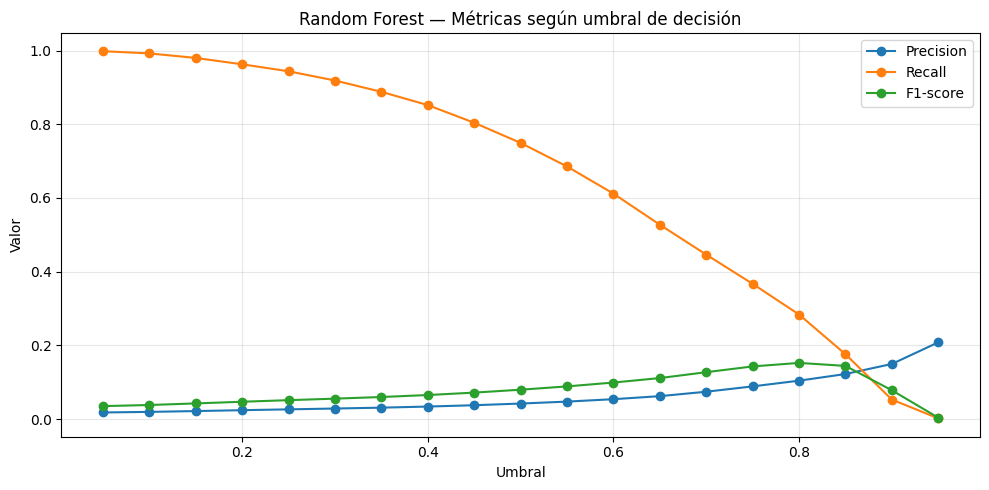

In [9]:
# =========================================================
# AJUSTE DE UMBRAL PARA RANDOM FOREST
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

umbrales = np.arange(0.05, 0.96, 0.05)

resultados_umbrales_rf = []

for umbral in umbrales:
    y_pred_umbral = (y_proba >= umbral).astype(int)

    precision = precision_score(y_test, y_pred_umbral, zero_division=0)
    recall = recall_score(y_test, y_pred_umbral, zero_division=0)
    f1 = f1_score(y_test, y_pred_umbral, zero_division=0)

    cm = confusion_matrix(y_test, y_pred_umbral)
    tn, fp, fn, tp = cm.ravel()

    resultados_umbrales_rf.append({
        "umbral": umbral,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "verdaderos_positivos": tp,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdaderos_negativos": tn
    })

df_umbrales_rf = pd.DataFrame(resultados_umbrales_rf)

display(df_umbrales_rf.round(4))

mejor_f1_rf = df_umbrales_rf.loc[df_umbrales_rf["f1"].idxmax()]

print("="*70)
print("MEJOR UMBRAL RANDOM FOREST SEGÚN F1")
print("="*70)
display(mejor_f1_rf.to_frame().T.round(4))

plt.figure(figsize=(10, 5))

plt.plot(df_umbrales_rf["umbral"], df_umbrales_rf["precision"], marker="o", label="Precision")
plt.plot(df_umbrales_rf["umbral"], df_umbrales_rf["recall"], marker="o", label="Recall")
plt.plot(df_umbrales_rf["umbral"], df_umbrales_rf["f1"], marker="o", label="F1-score")

plt.title("Random Forest — Métricas según umbral de decisión")
plt.xlabel("Umbral")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# =========================================================
# CHUNK — MÉTRICAS FINALES RANDOM FOREST CON UMBRAL 0.80
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score
)

import pandas as pd
import numpy as np

# Mejor umbral encontrado
UMBRAL_RF_FINAL = 0.80

# Probabilidades del Random Forest
# En tu notebook parece llamarse y_proba
y_pred_rf_final = (y_proba >= UMBRAL_RF_FINAL).astype(int)

# Métricas finales
accuracy_rf = accuracy_score(y_test, y_pred_rf_final)
precision_rf = precision_score(y_test, y_pred_rf_final, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf_final, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf_final, zero_division=0)
pr_auc_rf = average_precision_score(y_test, y_proba)
roc_auc_rf = roc_auc_score(y_test, y_proba)

# Matriz de confusión
cm_rf_final = confusion_matrix(y_test, y_pred_rf_final)
tn, fp, fn, tp = cm_rf_final.ravel()

metricas_rf_final = pd.DataFrame([{
    "modelo": "Random Forest balanceado",
    "umbral": UMBRAL_RF_FINAL,
    "accuracy": accuracy_rf,
    "precision": precision_rf,
    "recall": recall_rf,
    "f1": f1_rf,
    "pr_auc": pr_auc_rf,
    "roc_auc": roc_auc_rf,
    "tp": tp,
    "fp": fp,
    "fn": fn,
    "tn": tn
}])

display(metricas_rf_final.round(4))

print("="*70)
print(f"MATRIZ DE CONFUSIÓN — RANDOM FOREST UMBRAL {UMBRAL_RF_FINAL}")
print("="*70)

display(pd.DataFrame(
    cm_rf_final,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf_final, zero_division=0))

,modelo,umbral,accuracy,precision,recall,f1,pr_auc,roc_auc,tp,fp,fn,tn
0,Random Forest balanceado,0.8,0.9469,0.1042,0.2837,0.1524,0.0769,0.8069,6956,59825,17561,1374070


MATRIZ DE CONFUSIÓN — RANDOM FOREST UMBRAL 0.8


,Pred 0,Pred 1
Real 0,1374070,59825
Real 1,17561,6956



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97   1433895
           1       0.10      0.28      0.15     24517

    accuracy                           0.95   1458412
   macro avg       0.55      0.62      0.56   1458412
weighted avg       0.97      0.95      0.96   1458412



TOP 20 VARIABLES RANDOM FOREST


,variable,importancia
13,prom_accidentes_historico_barrio,0.385315
0,temperature,0.099052
8,hora_cos,0.065243
14,barrio_id,0.058656
3,windSpeed,0.056599
1,dewPoint,0.055949
2,humidity,0.053387
7,hora_sin,0.046990
11,dia_ano_sin,0.046316
12,dia_ano_cos,0.046119


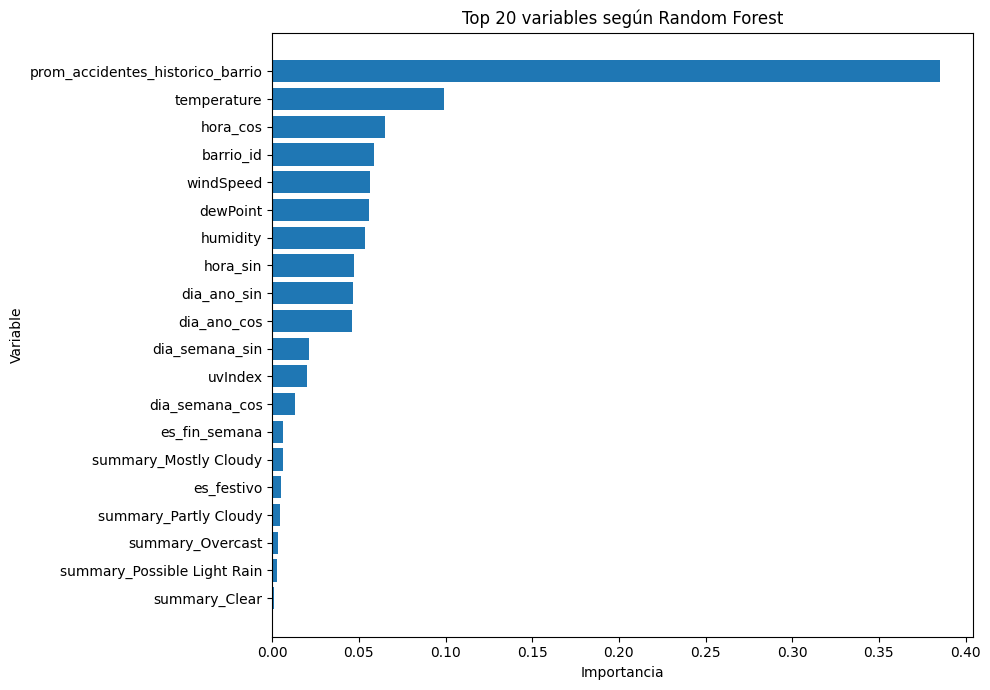

In [11]:
# =========================================================
# CHUNK — IMPORTANCIA DE VARIABLES RANDOM FOREST
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# 1. Verificar de dónde tomar los nombres de columnas
if "cols_X" in globals():
    feature_names = cols_X
elif "X_train_bal" in globals():
    feature_names = X_train_bal.columns.tolist()
elif "X_train" in globals():
    feature_names = X_train.columns.tolist()
else:
    raise ValueError("No encuentro cols_X, X_train_bal ni X_train para obtener nombres de variables.")

# 2. Verificar que exista el modelo
if "modelo_rf" not in globals():
    raise ValueError("No existe modelo_rf. Revisa el nombre del modelo Random Forest entrenado.")

# 3. Crear tabla de importancias
importancias_rf = pd.DataFrame({
    "variable": feature_names,
    "importancia": modelo_rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("="*70)
print("TOP 20 VARIABLES RANDOM FOREST")
print("="*70)

display(importancias_rf.head(20))

# 4. Gráfico top 20
top_n = 20
top_importancias = importancias_rf.head(top_n).sort_values("importancia")

plt.figure(figsize=(10, 7))
plt.barh(
    top_importancias["variable"],
    top_importancias["importancia"]
)

plt.title("Top 20 variables según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

En el modelo Random Forest, la variable con mayor importancia fue `prom_accidentes_historico_barrio`, lo que indica que el comportamiento histórico de accidentalidad del barrio es la señal más relevante para la predicción. También se destacan variables temporales como `hora_cos`, `hora_sin` y `dia_ano_sin/cos`, lo que confirma la importancia de la dimensión temporal en el problema. Entre las variables climáticas, `temperature`, `windSpeed`, `dewPoint` y `humidity` presentan mayor aporte, en concordancia con el análisis exploratorio. Las variables categóricas derivadas de `summary` tienen menor importancia relativa, por lo que su contribución al modelo parece ser secundaria frente al historial espacial, el tiempo y las condiciones climáticas numéricas.

In [12]:
# =========================================================
# EXPORTAR MÉTRICAS RF PARA COMPARACIÓN ENTRE NOTEBOOKS
# =========================================================
from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

ruta_metricas_rf = ARTIFACTS_DIR / "metricas_rf.csv"
metricas_rf_final.to_csv(ruta_metricas_rf, index=False)

print(f"Métricas RF guardadas en: {ruta_metricas_rf.resolve()}")
display(metricas_rf_final.round(4))

Métricas RF guardadas en: C:\Users\camil\OneDrive\Documentos\Aprendizaje de Maquina\Taller\Modelado\artifacts\metricas_rf.csv


,modelo,umbral,accuracy,precision,recall,f1,pr_auc,roc_auc,tp,fp,fn,tn
0,Random Forest balanceado,0.8,0.9469,0.1042,0.2837,0.1524,0.0769,0.8069,6956,59825,17561,1374070
